**Used Libraries**

In [1]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt

**Drive mount**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

**Unzip the files in the Olist folder**

In [ ]:
zip_file_path = '/content/drive/MyDrive/olist/archive.zip'
destination_folder = '/content/drive/MyDrive/olist/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_folder)

extracted_files = os.listdir(destination_folder)
print("Extracted files:", extracted_files)

Extracted files: ['archive.zip', '.ipynb_checkpoints', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


**List the files and their columns**

In [ ]:
dataset_columns = {}

for file in extracted_files:
    if file.endswith('.csv'):  # Only process CSV files
        file_path = os.path.join(destination_folder, file)
        df = pd.read_csv(file_path)
        dataset_columns[file] = df.columns.tolist()

for file, columns in dataset_columns.items():
    print(f"File: {file}")
    print(f"Columns: {columns}\n")

File: olist_customers_dataset.csv
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

File: olist_geolocation_dataset.csv
Columns: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

File: olist_order_items_dataset.csv
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

File: olist_order_payments_dataset.csv
Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

File: olist_order_reviews_dataset.csv
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

File: olist_orders_dataset.csv
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated

# **Fix missing Values**

**List missing values**

In [2]:
destination_folder = '/content/drive/MyDrive/olist/'

extracted_files = os.listdir(destination_folder)

# Dictionary to store missing values summary
missing_values_summary = {}

# Check missing values for each file
for file in extracted_files:
    if file.endswith('.csv'):
        file_path = os.path.join(destination_folder, file)
        df = pd.read_csv(file_path)
        missing_values = df.isnull().sum()

        missing_columns = missing_values[missing_values > 0]
        if len(missing_columns) > 0:
            missing_values_summary[file] = missing_columns.to_dict()

print(missing_values_summary)

NameError: name 'os' is not defined

**Missing Values Summary (by Dataset)**


1. olist_order_reviews_dataset.csv

| Column Name            | Missing Count |
| ---------------------- | ------------- |
| review_comment_title   | 87,656        |
| review_comment_message | 58,247        |


2. olist_orders_dataset.csv

| Column Name                   | Missing Count |
| ----------------------------- | ------------- |
| order_approved_at             | 160           |
| order_delivered_carrier_date  | 1,783         |
| order_delivered_customer_date | 2,965         |


3. olist_products_dataset.csv

| Column Name                | Missing Count |
| -------------------------- | ------------- |
| product_category_name      | 610           |
| product_name_lenght        | 610           |
| product_description_lenght | 610           |
| product_photos_qty         | 610           |
| product_weight_g           | 2             |
| product_length_cm          | 2             |
| product_height_cm          | 2             |
| product_width_cm           | 2             |


**Missing Values Cleaning (All Datasets)**

In [ ]:
# Set new folder for storing fixed files for next step

base_path = '/content/drive/MyDrive/olist/'
output_path = '/content/drive/MyDrive/olist/fixed_missing/'

os.makedirs(output_path, exist_ok=True)


# olist_order_reviews_dataset.csv

# Strategy:

#   - Text fields are optional → we replace missing values with "No Comment"

reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')

reviews['review_comment_title'] = reviews['review_comment_title'].fillna('No Comment')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No Comment')

reviews.to_csv(output_path + 'olist_order_reviews_dataset.csv', index=False)


# olist_orders_dataset.csv

# Strategy:

#    - Missing delivery timestamps indicate cancelled / undelivered orders
#    - We keep them as NaT (do NOT impute)
#    - Convert all timestamp columns to datetime

orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders.to_csv(output_path + 'olist_orders_dataset.csv', index=False)


# olist_products_dataset.csv

# Strategy:

#   - Missing product metadata → We label as "unknown"
#   - Physical dimensions missing (only 2 rows) → We fill with column median

products = pd.read_csv(base_path + 'olist_products_dataset.csv')

# Categorical / descriptive fields
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].median())
products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_description_lenght'].median())
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())

# Physical dimensions (very small missing count)
dimension_cols = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in dimension_cols:
    products[col] = products[col].fillna(products[col].median())

products.to_csv(output_path + 'olist_products_dataset.csv', index=False)


# Files with NO missing values (saved unchanged for consistency)

files_no_missing = [
    'olist_customers_dataset.csv',
    'olist_sellers_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_geolocation_dataset.csv',
    'product_category_name_translation.csv'
]

for file in files_no_missing:
    df = pd.read_csv(base_path + file)
    df.to_csv(output_path + file, index=False)

**Justification**



*   Order Reviews: Missing comments were replaced with "No Comment" because review text is optional and does not affect sentiment analysis based on scores.

*   Orders: Missing delivery timestamps were preserved as NaT since they represent cancelled or undelivered orders, which is analytically meaningful.


*   Products: Missing category and descriptive metadata were labeled as "unknown", while rare missing physical dimensions were imputed using medians to preserve numeric integrity.


*   Other Files: Datasets without missing values were saved unchanged to maintain a consistent cleaned-data pipeline.

**Duplicate Keys Check (All Cleaned Files in fixed_missing folder)**

In [ ]:
clean_path = '/content/drive/MyDrive/olist/fixed_missing/'

# Define expected primary keys per file
primary_keys = {
    'olist_orders_dataset.csv': ['order_id'],
    'olist_order_reviews_dataset.csv': ['review_id'],
    'olist_order_items_dataset.csv': ['order_id', 'order_item_id'],
    'olist_order_payments_dataset.csv': ['order_id', 'payment_sequential'],
    'olist_customers_dataset.csv': ['customer_id'],
    'olist_sellers_dataset.csv': ['seller_id'],
    'olist_products_dataset.csv': ['product_id'],
    'olist_geolocation_dataset.csv': ['geolocation_zip_code_prefix'],
    'product_category_name_translation.csv': ['product_category_name']
}

duplicate_summary = {}

for file, keys in primary_keys.items():
    file_path = os.path.join(clean_path, file)
    df = pd.read_csv(file_path)

    dup_count = df.duplicated(subset=keys).sum()

    if dup_count > 0:
        duplicate_summary[file] = {
            'key_columns': keys,
            'duplicate_rows': int(dup_count)
        }

print(duplicate_summary)

{'olist_order_reviews_dataset.csv': {'key_columns': ['review_id'], 'duplicate_rows': 814}, 'olist_geolocation_dataset.csv': {'key_columns': ['geolocation_zip_code_prefix'], 'duplicate_rows': 981148}}


**Duplicate Keys Summary (by Dataset)**

1. olist_order_reviews_dataset.csv

| Key Column | Duplicate Rows |
| ---------- | -------------- |
| review_id  | 814            |



Interpretation:

Each review should have a unique review_id. The presence of duplicates indicates repeated review records for the same review identifier, likely caused by data ingestion or replication issues. These duplicates will need to be removed while keeping one valid record per review_id.


2. olist_geolocation_dataset.csv

| Key Column                  | Duplicate Rows |
| --------------------------- | -------------- |
| geolocation_zip_code_prefix | 981,148        |


Interpretation:

olist dataset intentionally contains multiple latitude/longitude points for the same zip code prefix. These are not true duplicates, but multiple observations per location.

**Remove Duplicate Keys**

In [ ]:
# New folder for fixed duplicate keys files
input_path = '/content/drive/MyDrive/olist/fixed_missing/'
output_path = '/content/drive/MyDrive/olist/removed_duplicate/'

os.makedirs(output_path, exist_ok=True)


# Fix duplicates in olist_order_reviews_dataset.csv

# Rule applied:

#   - Keep one record per review_id
#   - Drop duplicated review_id rows (first occurrence kept)


reviews = pd.read_csv(input_path + 'olist_order_reviews_dataset.csv')

reviews_deduped = reviews.drop_duplicates(subset=['review_id'], keep='first')

reviews_deduped.to_csv(output_path + 'olist_order_reviews_dataset.csv', index=False)

# Copy all other files unchanged (no true duplicates)
files_no_dedup = [
    'olist_orders_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_customers_dataset.csv',
    'olist_sellers_dataset.csv',
    'olist_products_dataset.csv',
    'olist_geolocation_dataset.csv',
    'product_category_name_translation.csv'
]

for file in files_no_dedup:
    df = pd.read_csv(input_path + file)
    df.to_csv(output_path + file, index=False)

**Timestamp → Datetime Fix**

In [ ]:
# Setup new folder for fixed timestamps
input_path = '/content/drive/MyDrive/olist/removed_duplicate/'
output_path = '/content/drive/MyDrive/olist/fixed_time/'

os.makedirs(output_path, exist_ok=True)

# Fix timestamps in olist_orders_dataset.csv
orders = pd.read_csv(input_path + 'olist_orders_dataset.csv')

order_date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders.to_csv(output_path + 'olist_orders_dataset.csv', index=False)


# Fix timestamps in olist_order_reviews_dataset.csv
reviews = pd.read_csv(input_path + 'olist_order_reviews_dataset.csv')

review_date_cols = [
    'review_creation_date',
    'review_answer_timestamp'
]

for col in review_date_cols:
    reviews[col] = pd.to_datetime(reviews[col], errors='coerce')

reviews.to_csv(output_path + 'olist_order_reviews_dataset.csv', index=False)


# Fix timestamps in olist_order_items_dataset.csv
items = pd.read_csv(input_path + 'olist_order_items_dataset.csv')

items['shipping_limit_date'] = pd.to_datetime(
    items['shipping_limit_date'], errors='coerce'
)

items.to_csv(output_path + 'olist_order_items_dataset.csv', index=False)


# Copy files with NO datetime columns unchanged
files_no_time_fix = [
    'olist_customers_dataset.csv',
    'olist_sellers_dataset.csv',
    'olist_products_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_geolocation_dataset.csv',
    'product_category_name_translation.csv'
]

for file in files_no_time_fix:
    df = pd.read_csv(input_path + file)
    df.to_csv(output_path + file, index=False)

**All timestamp columns are:**

*   Properly converted to datetime
*   Ready for delivery-time calculations, trends, and Power BI modeling

**Outlier Checks (Boxplots + Delivery Time)**

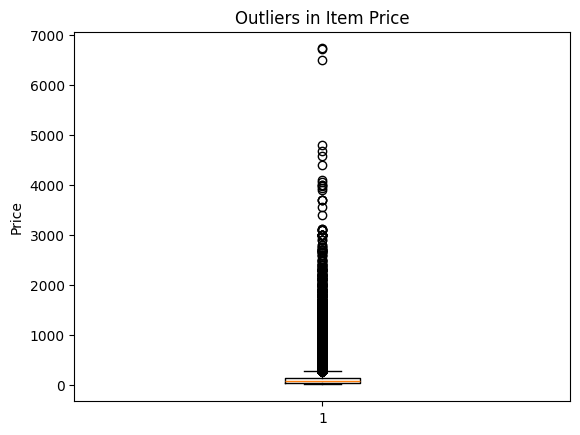

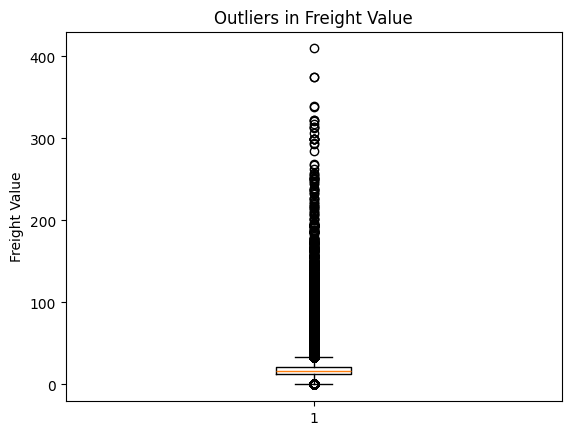

In [ ]:
# Price & Freight Value (olist_order_items_dataset.csv)
items = pd.read_csv('/content/drive/MyDrive/olist/fixed_time/olist_order_items_dataset.csv')

# Boxplot for price
plt.figure()
plt.boxplot(items['price'].dropna())
plt.title('Outliers in Item Price')
plt.ylabel('Price')
plt.show()

# Boxplot for freight_value
plt.figure()
plt.boxplot(items['freight_value'].dropna())
plt.title('Outliers in Freight Value')
plt.ylabel('Freight Value')
plt.show()

**1. Item Price Outliers — Interpretation**

What the plot shows:

*   The box (IQR) is close to 0, but the price distribution is spread across a wide range, indicating a diversity of products across various price points.

*   There is a very long upper tail, with prices extending up to ~4,000.

*   Many dots above the whisker represent high-value products, with some extreme prices above 4,000.


What this means analytically:

*   These are real, legitimate prices (e.g., high-end electronics, premium furniture, bulk items).

*   This is a right-skewed distribution, indicating that while most products are moderately priced, there is a substantial number of high-value items driving the upper range.

*   Removing these outliers would distort revenue analysis, particularly when evaluating top-selling products and large-ticket items.

Conclusion:

*   These are valid business outliers, not data quality issues.


**2. Freight Value Outliers — Interpretation**

What the plot shows:

*   Most freight values typically range between 0 and 100, with some occasional higher values.

*   The plot shows a long tail up to ~400, indicating high freight costs for specific shipments (e.g., heavy, bulky, or long-distance deliveries).

*   There are several sparse outliers, but they are significant for analysis of high-shipping-cost items.


What this means analytically:

*   High freight costs are expected for:

      *   Heavy products

      *   Long-distance deliveries

      *   Remote regions or less-accessible regions

*  These freight outliers are important for logistics analysis, as they reflect shipping challenges and the impact of delivery costs on profit margins.

Conclusion:

*   Freight outliers are analytically meaningful, not errors. They provide valuable insights into shipping costs and should be preserved for logistic performance analysis.


*Boxplot analysis revealed extreme values in item price and freight cost distributions. These outliers reflect legitimate high-value products and long-distance or heavy-item deliveries rather than data errors. Therefore, no outlier removal was applied to preserve business realism and analytical integrity.*

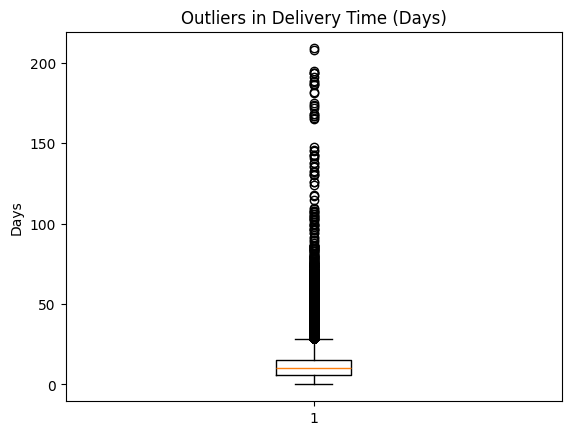

In [ ]:
# Delivery Time Calculation (olist_orders_dataset.csv)

#   - Delivery time = order_delivered_customer_date − order_purchase_timestamp

orders = pd.read_csv('/content/drive/MyDrive/olist/fixed_time/olist_orders_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'], errors='coerce'
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'], errors='coerce'
)

orders['delivery_time_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days


plt.figure()
plt.boxplot(orders['delivery_time_days'].dropna())
plt.title('Outliers in Delivery Time (Days)')
plt.ylabel('Days')
plt.show()

**3. Delivery Time Outliers — Interpretation**

What the plot shows

*   The median delivery time is relatively low (~5-10 days)

*   The IQR (box) is compact → most deliveries are completed within a reasonable timeframe

*   There is a long right tail, with deliveries extending beyond 100–200 days, representing delayed deliveries.

*   Many dots above the whisker = extreme late deliveries

What this means analytically:

*   Orders that were:

    *   Delayed due to logistics issues

    *   Held at carrier level

    *   Affected by seller delays

*   Orders that may have been:

    *   Delivered extremely late

    *   Operationally problematic, which is central to our analysis

  *Delivery time distributions show a strong right skew with extreme late deliveries. These outliers represent genuine operational delays rather than data errors and are therefore retained to preserve analytical validity, particularly for evaluating delivery performance and customer dissatisfaction.*

**Dataset Join: Merging All Datasets**

This step merges all operational datasets into analysis-ready item-level and order-level tables while deliberately excluding geolocation to prevent row explosion and analytical distortion.

In [ ]:
clean_path = '/content/drive/MyDrive/olist/fixed_time/'
output_path = '/content/drive/MyDrive/olist/final_datasets/'
os.makedirs(output_path, exist_ok=True)

# Load datasets
orders = pd.read_csv(clean_path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(clean_path + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(clean_path + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(clean_path + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(clean_path + 'olist_customers_dataset.csv')
sellers = pd.read_csv(clean_path + 'olist_sellers_dataset.csv')
products = pd.read_csv(clean_path + 'olist_products_dataset.csv')
category_translation = pd.read_csv(clean_path + 'product_category_name_translation.csv')
geolocation = pd.read_csv(clean_path + 'olist_geolocation_dataset.csv')

**Pre-Aggregate Payments**

Orders can have multiple payment rows. We aggregate before joining to avoid row explosion.

In [ ]:
payment_summary = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: ', '.join(x.unique()),
    'payment_installments': 'max'
}).reset_index()

payment_summary.rename(columns={
    'payment_value': 'total_payment_value',
    'payment_type': 'payment_methods'
}, inplace=True)

**Perform Joins (8 Datasets, NO GEOLOCATION)**

In [ ]:
# 1. Orders → Customers
df = orders.merge(customers, on='customer_id', how='left')

# 2. Orders → Order Items (ROW EXPANSION)
df = df.merge(order_items, on='order_id', how='left')

# 3. Items → Products
df = df.merge(products, on='product_id', how='left')

# 4. Products → Category Translation
df = df.merge(category_translation, on='product_category_name', how='left')

# 5. Items → Sellers
df = df.merge(sellers, on='seller_id', how='left')

# 6. Orders → Payments (pre-aggregated)
df = df.merge(payment_summary, on='order_id', how='left')

# 7. Orders → Reviews
df = df.merge(
    order_reviews[['order_id', 'review_score', 'review_creation_date']],
    on='order_id',
    how='left'
)

print(f"Final item-level dataset shape: {df.shape}")

Final item-level dataset shape: (113727, 35)


**Delivery Metrics**

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')

df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

df['estimated_delivery_time_days'] = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

df['delivery_delay_days'] = (
    df['delivery_time_days'] -
    df['estimated_delivery_time_days']
)

df['delivery_status'] = df['delivery_delay_days'].apply(
    lambda x: 'Early' if x < 0 else
              'On-Time' if x == 0 else
              'Late' if x > 0 else
              'Not Delivered'
)

**Save ITEM-LEVEL Dataset**

In [ ]:
df.to_csv(output_path + 'olist_master_item_level.csv', index=False)

We will Use for:

*   Product analysis

*   Seller performance

*   Category comparisons

**Create ORDER-LEVEL Dataset (Aggregation)**

In [ ]:
order_level = df.groupby('order_id').agg({
    'customer_id': 'first',
    'customer_state': 'first',
    'customer_city': 'first',
    'customer_zip_code_prefix': 'first',
    'order_status': 'first',
    'order_purchase_timestamp': 'first',
    'order_delivered_customer_date': 'first',
    'order_estimated_delivery_date': 'first',
    'delivery_time_days': 'first',
    'delivery_delay_days': 'first',
    'delivery_status': 'first',
    'price': 'sum',
    'freight_value': 'sum',
    'total_payment_value': 'first',
    'payment_methods': 'first',
    'review_score': 'first',
    'order_item_id': 'count'
}).reset_index()

order_level.rename(columns={
    'price': 'total_price',
    'freight_value': 'total_freight',
    'order_item_id': 'items_per_order'
}, inplace=True)

order_level['total_revenue'] = (
    order_level['total_price'] + order_level['total_freight']
)

order_level.to_csv(output_path + 'olist_master_order_level.csv', index=False)

**Geolocation: NOT Merged**

Geolocation was not merged into the main dataset because each zip code contains multiple latitude–longitude points, which would cause massive row duplication and invalidate analytical results.

We have created a SAFE lookup table instead

In [ ]:
geo_lookup = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

geo_lookup.to_csv(output_path + 'olist_geolocation_lookup.csv', index=False)

We Use for:

*   Power BI maps

*   Relationships on customer_zip_code_prefix


| File                           | Purpose                              |
| ------------------------------ | ------------------------------------ |
| `olist_master_item_level.csv`  | Product / seller / category analysis |
| `olist_master_order_level.csv` | Revenue trends & delivery KPIs       |
| `olist_geolocation_lookup.csv` | Mapping (Power BI relationship)      |

We have consolidated the Olist dataset into analysis-ready tables by using orders as the central fact table and applying LEFT joins to preserve all orders, even when related information is missing. Customer, item, product, seller, payment, and review datasets are joined using their natural keys to enrich each order with operational, commercial, and satisfaction attributes. Payment data is pre-aggregated at the order level to prevent row duplication caused by multiple payment records. Multi-item orders are handled through controlled row expansion at the item level and aggregation at the order level. The geolocation dataset is deliberately excluded from the main merge due to its multiple coordinates per zip code and is instead provided as a separate lookup table for spatial analysis in Power BI.